# Feature Importance Bar Chart
Horizontal bar chart of the top meta-features ranked by Random Forest importance scores.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Feature Importance Data
Top 10 from the thesis results. **Replace or extend this with your full importance scores** 
from `rf_model.feature_importances_` if you have the trained model saved.

In [ ]:

importances = {
    'lh_trace': 0.048817,
    'dist_skew': 0.045090,
    'roy_root': 0.044575,
    'w_lambda': 0.043304,
    'dist_std': 0.040002,
    'can_cor.mean': 0.035487,
    'p_trace': 0.034714,
    'median.sd': 0.032579,
    'min.mean': 0.030941,
    'gravity': 0.029260,
}



# Sort and select top N
N = len(importances)  
sorted_features = sorted(importances.items(), key=lambda x: x[1], reverse=False)
sorted_features = sorted_features[-N:]  

names = [f[0] for f in sorted_features]
scores = [f[1] for f in sorted_features]

print(f'Plotting top {N} features')

Plotting top 10 features


## Horizontal Bar Chart

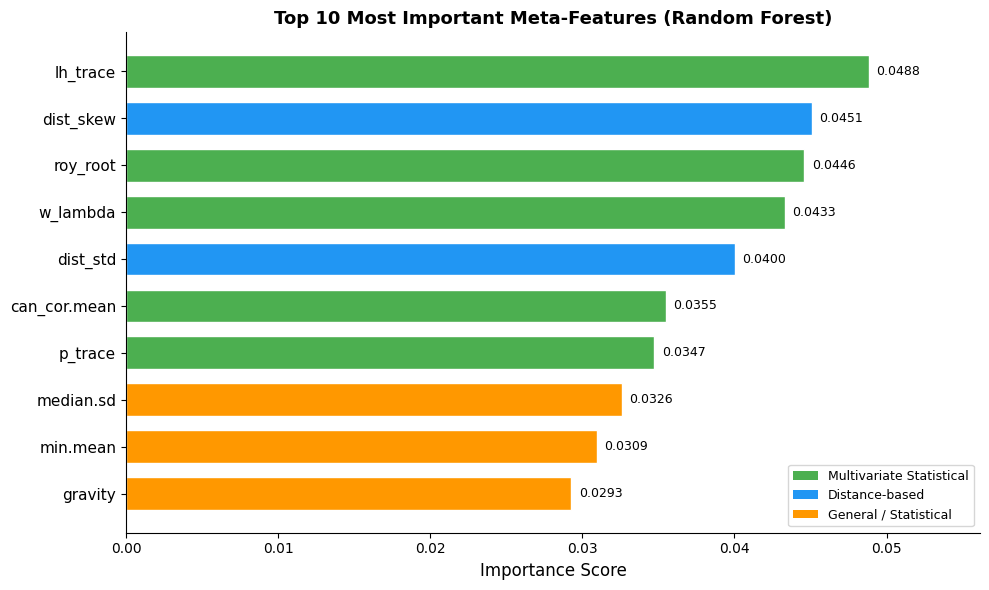

In [ ]:
# Color coding by feature category
category_colors = {
    'dist_skew': '#2196F3',     # distance-based (blue)
    'dist_std': '#2196F3',
    'dist_mean': '#2196F3',
    'dist_kurtosis': '#2196F3',
    'lh_trace': '#4CAF50',      # multivariate statistical (green)
    'roy_root': '#4CAF50',
    'w_lambda': '#4CAF50',
    'p_trace': '#4CAF50',
    'can_cor.mean': '#4CAF50',
}
default_color = '#FF9800'  # general/statistical (orange)

colors = [category_colors.get(name, default_color) for name in names]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(range(len(names)), scores, color=colors, edgecolor='white', height=0.7)

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=11)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 10 Most Important Meta-Features (Random Forest)', fontsize=13, fontweight='bold')

# Value labels on bars
for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=9)

# Legend for categories
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', label='Multivariate Statistical'),
    Patch(facecolor='#2196F3', label='Distance-based'),
    Patch(facecolor='#FF9800', label='General / Statistical'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlim(0, max(scores) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance_chart.png', dpi=300, bbox_inches='tight',
            facecolor='white', pad_inches=0.2)
plt.show()